In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
try:
    df = pd.read_csv('srilanka_disaster_data.csv')
    print("Data loaded successfully!")
    print(df.head())
except:
    print("File not found. Please create the CSV file first.")
print(df.isnull().sum())
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Rainfall_Today_mm', y='Water_Level_m', hue='Disaster_Occurred')
plt.title('Rainfall vs Water Level in Sri Lanka')
plt.show()

Data loaded successfully!
         Date      District  Rainfall_Today_mm  Cumulative_7Day_mm  \
0  2021-01-31  Nuwara Eliya               4.24               47.55   
1  2022-08-15       Badulla               5.02               20.23   
2  2020-01-18       Colombo               3.76               22.07   
3  2019-11-18       Badulla               5.03               39.05   
4  2021-07-21  Nuwara Eliya             135.26              307.57   

   Slope_Angle  Elevation_m  Disaster_Occurred  Intensity_Score  
0        42.78      1801.59                  0             0.09  
1        41.06       682.71                  0             0.08  
2         3.63        -2.62                  0             0.07  
3        42.28       679.83                  0             0.07  
4        45.19      1803.32                  1             3.80  
Date                  0
District              0
Rainfall_Today_mm     0
Cumulative_7Day_mm    0
Slope_Angle           0
Elevation_m           0
Disaster_Occu

ValueError: Could not interpret value `Water_Level_m` for `y`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

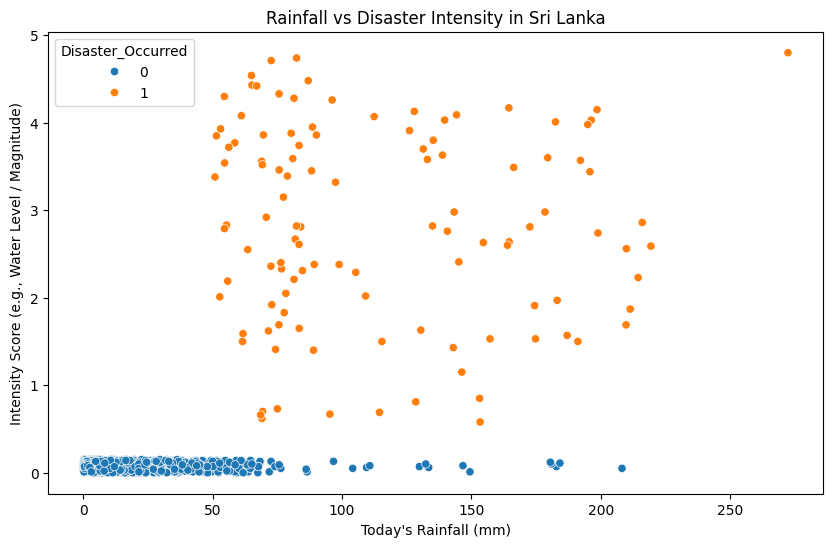

In [5]:
plt.figure(figsize=(10,6))

# Change y='Water_Level_m' to y='Intensity_Score'
sns.scatterplot(data=df, x='Rainfall_Today_mm', y='Intensity_Score', hue='Disaster_Occurred')

plt.title('Rainfall vs Disaster Intensity in Sri Lanka')
plt.xlabel('Today\'s Rainfall (mm)')
plt.ylabel('Intensity Score (e.g., Water Level / Magnitude)')
plt.show()

In [6]:
print(df.columns)

Index(['Date', 'District', 'Rainfall_Today_mm', 'Cumulative_7Day_mm',
       'Slope_Angle', 'Elevation_m', 'Disaster_Occurred', 'Intensity_Score'],
      dtype='str')


In [7]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Select the features that "cause" the disaster
# We use today's rain, the week's total, the slope, and elevation
features = ['Rainfall_Today_mm', 'Cumulative_7Day_mm', 'Slope_Angle', 'Elevation_m']
X = df[features]
y = df['Intensity_Score']

# 2. Split the data: 80% to learn from, 20% to test its knowledge
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Create and Train the model
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5)
model.fit(X_train, y_train)

# 4. Check how well it learned (The "Report Card")
predictions = model.predict(X_test)
accuracy = r2_score(y_test, predictions)

print(f"AI Training Complete!")
print(f"Model Accuracy (R2 Score): {accuracy * 100:.2f}%")

AI Training Complete!
Model Accuracy (R2 Score): 75.14%


In [8]:
# Create a fake weather report: 
# Today's Rain: 180mm | 7-Day Rain: 450mm | Slope: 42 degrees | Elevation: 600m
new_scenario = [[180, 450, 42, 600]]
risk_prediction = model.predict(new_scenario)

print(f"--- AI PREDICTION ---")
print(f"Predicted Intensity Level: {risk_prediction[0]:.2f}")

if risk_prediction[0] > 1.5:
    print("STATUS: RED ALERT! High Landslide/Flood Probability.")
else:
    print("STATUS: GREEN. No immediate threat detected.")

--- AI PREDICTION ---
Predicted Intensity Level: 3.22
STATUS: RED ALERT! High Landslide/Flood Probability.


In [9]:
# --- TEST A SPECIFIC SCENARIO ---

# 1. Enter the numbers for Hambantota
# Format: [Rainfall_Today, Cumulative_7Day, Slope_Angle, Elevation]
hambantota_data = [[20, 45, 5, 10]] # 20mm rain, 45mm week total, low slope, low elevation

# 2. Ask the AI for the prediction
result = model.predict(hambantota_data)

print(f"--- RESULTS FOR HAMBANTOTA ---")
print(f"Predicted Risk Intensity: {result[0]:.4f}")

if result[0] > 1.0:
    print("STATUS: ALERT! Potential Flood/Disaster.")
else:
    print("STATUS: SAFE. Risk is very low.")

--- RESULTS FOR HAMBANTOTA ---
Predicted Risk Intensity: 0.0634
STATUS: SAFE. Risk is very low.


In [10]:
# Change the numbers to: 200mm rain, 500mm week total, 40 degree slope
kegalle_danger = [[200, 500, 40, 150]] 
result = model.predict(kegalle_danger)
print(f"Risk Level: {result[0]}")

Risk Level: 2.7949628829956055
